<a href="https://colab.research.google.com/github/miguel-duque06/exercicios_introducao_ciencia_dados/blob/main/Analise__exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória para uma empresa de chocolate:

![Chocolate](https://i.ytimg.com/vi/301nEGzgW10/maxresdefault.jpg)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = '/content/drive/MyDrive/Chocolate Sales.csv'

In [3]:
dados_nulos = pd.read_csv(url)

In [4]:
dados_chocolate = dados_nulos.dropna()

#A empresa quer saber quem é o melhor vendedor
Objetivo: Identificar o vendedor com maior performance comercial através da análise do dataset Chocolate_Sales.csv contendo informações de Sales Person, Country, Product, Date, Amount e Boxes Shipped.





![Vendedor](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQAkmmsXPLDoxrt-kyes-U0VOkVnHTZcZKLVw&s)

Limpando os dados da coluna "Amount" e tornando-os em float

In [5]:
dados_chocolate['Amount'] = (
    dados_chocolate['Amount']
    .astype(str)
    .str.replace('[$]', '', regex=True)     # Remove $
    .str.replace(',', '', regex=False)       # Remove vírgulas milhar
    .astype(float)                          # Python lê os numeros depois do . como decimal
)

Calculo das vendas por vendedor

In [6]:
faturamento_vendedor = dados_chocolate.groupby('Sales Person').agg({
    'Amount': 'sum',
    'Boxes Shipped': 'sum'
}).round(2).sort_values('Amount', ascending=False)



In [7]:
faturamento_vendedor

,Amount,Boxes Shipped
Sales Person,,
Ches Bonnell,320901.0,7522
Oby Sorrel,316645.0,8608
Madelene Upcott,316099.0,7279
Brien Boise,312816.0,8102
Kelci Walkden,311710.0,8702
Van Tuxwell,303149.0,6799
Dennison Crosswaite,291669.0,8767
Beverie Moffet,278922.0,9214
Kaine Padly,266490.0,7253


#Gráfico do faturamento por vendedor

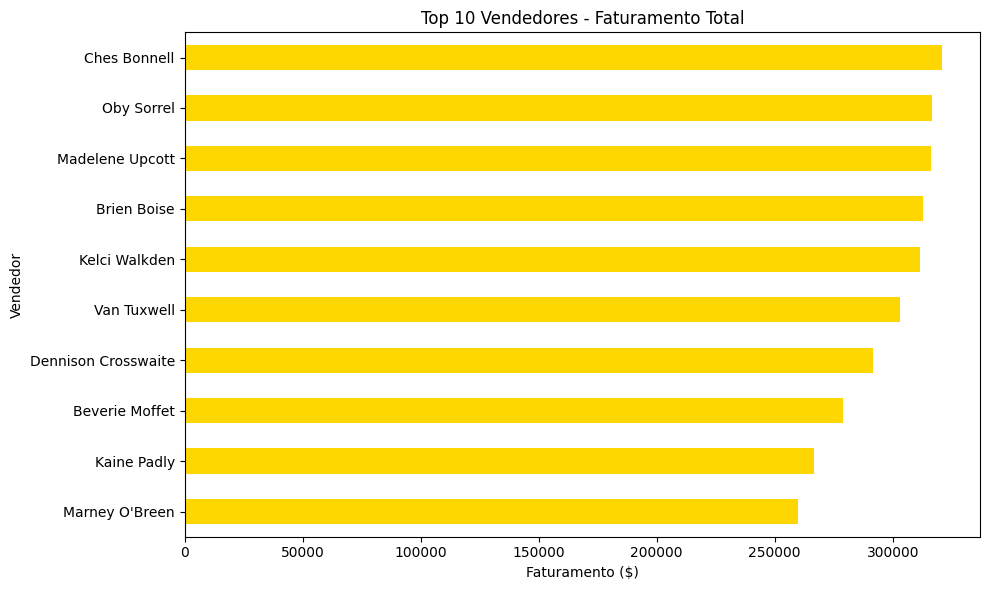

In [8]:
faturamento_top = faturamento_vendedor['Amount'].nlargest(10).sort_values(ascending=True)

faturamento_top.plot(kind='barh', figsize=(10,6), color='gold')
plt.title('Top 10 Vendedores - Faturamento Total')
plt.xlabel('Faturamento ($)')
plt.ylabel('Vendedor')
plt.tight_layout()
plt.show()

#A empresa está precisando deixar de vender um produto para diminuir os gastos
Objetivo: Identificar por meio de um gráfico qual produto está sendo menos vendido.

![Vendas caindo](https://img.freepik.com/fotos-premium/conceito-de-falencia-com-corrente-caindo-como-um-jogo-de-domino-e-diminuindo_207634-675.jpg?semt=ais_hybrid&w=740&q=80)

In [9]:
frequencia_produtos = dados_chocolate['Product'].value_counts().sort_values(ascending=False)

In [10]:
frequencia_produtos

,count
Product,
Eclairs,60
50% Dark Bites,60
Smooth Sliky Salty,59
White Choc,58
Drinking Coco,56
Spicy Special Slims,54
Organic Choco Syrup,52
85% Dark Bars,50
Fruit & Nut Bars,50


#Gráfico dos produtos vendidos

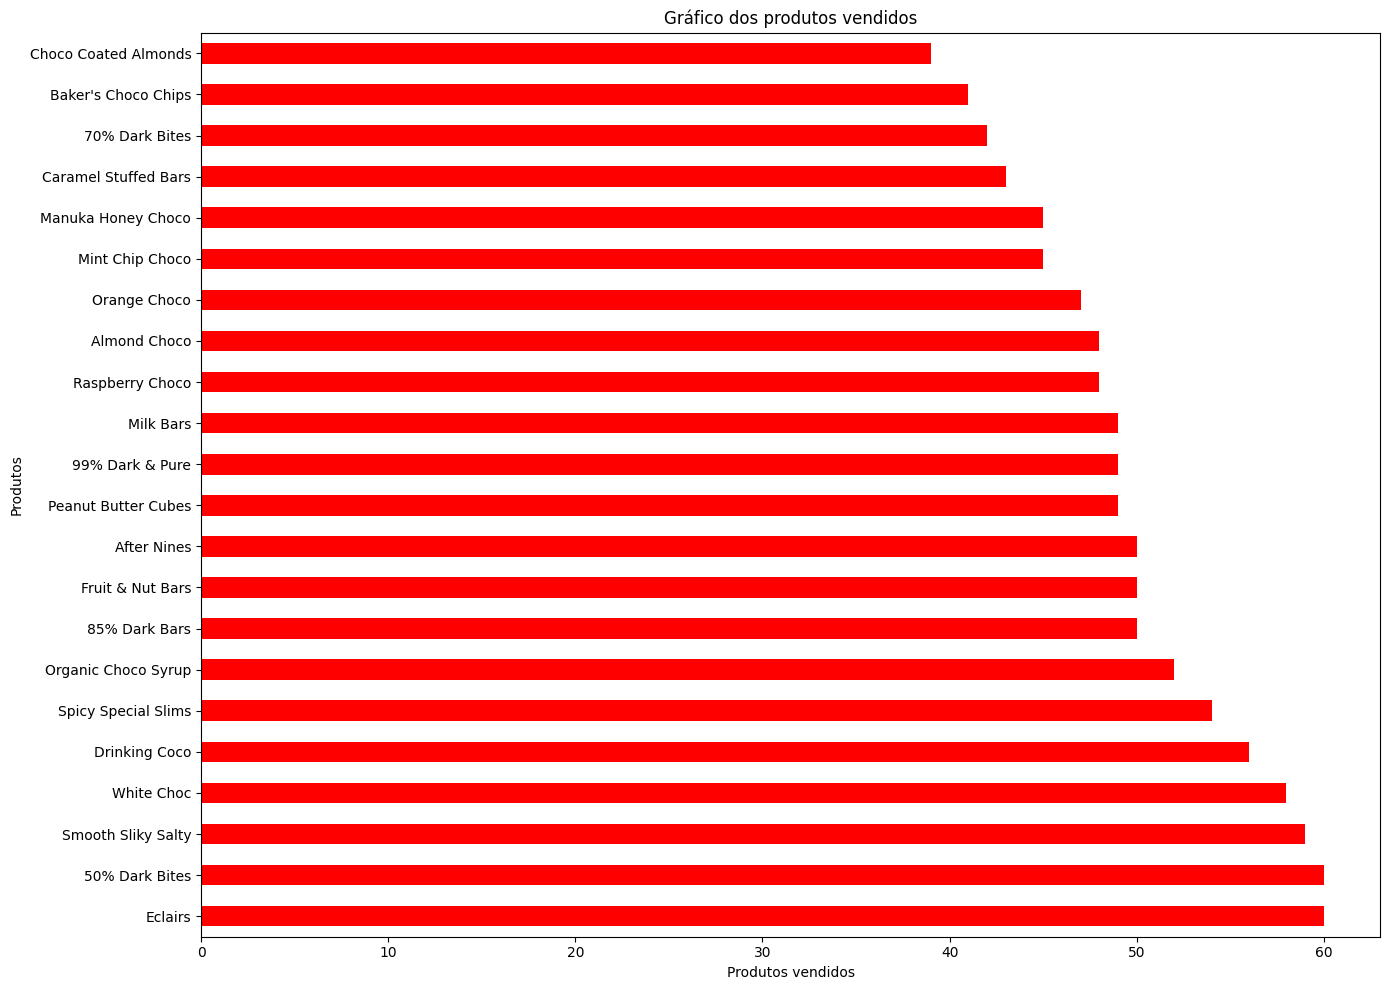

In [11]:
frequencia_produtos.plot(kind='barh', figsize=(14,10), color='red')
plt.title('Gráfico dos produtos vendidos')
plt.xlabel('Produtos vendidos')
plt.ylabel('Produtos')
plt.tight_layout()
plt.show()

![Vendas mundo](https://lh3.googleusercontent.com/gg/AMW1TPqQQWaYpbRDkPp2E66m_C_zw11k9sZeKWnHDXV5n13FD-ZL1vsyp0bPHSwas1U59nw2wx6UN8_cjbSr2uANsLYrzLhBCL27jmoG7itIKP7b7gt9iWXvN7qgRDjOgVBaJGblkkJ3EW686Wy_dwP7XFdOlpQSDbpKBSlH9LFxxsj09cFteay4=s1024-rj-mp2)

#Qual país recebe mais pedidos?

In [12]:
faturamento_pais = dados_chocolate['Country'].value_counts().sort_values(ascending=False)
faturamento_pais_graf = dados_chocolate['Country'].value_counts().sort_values()

In [13]:
faturamento_pais

,count
Country,
Australia,205
India,184
USA,179
UK,178
Canada,175
New Zealand,173


#Gráfico dos paises com mais pedidos

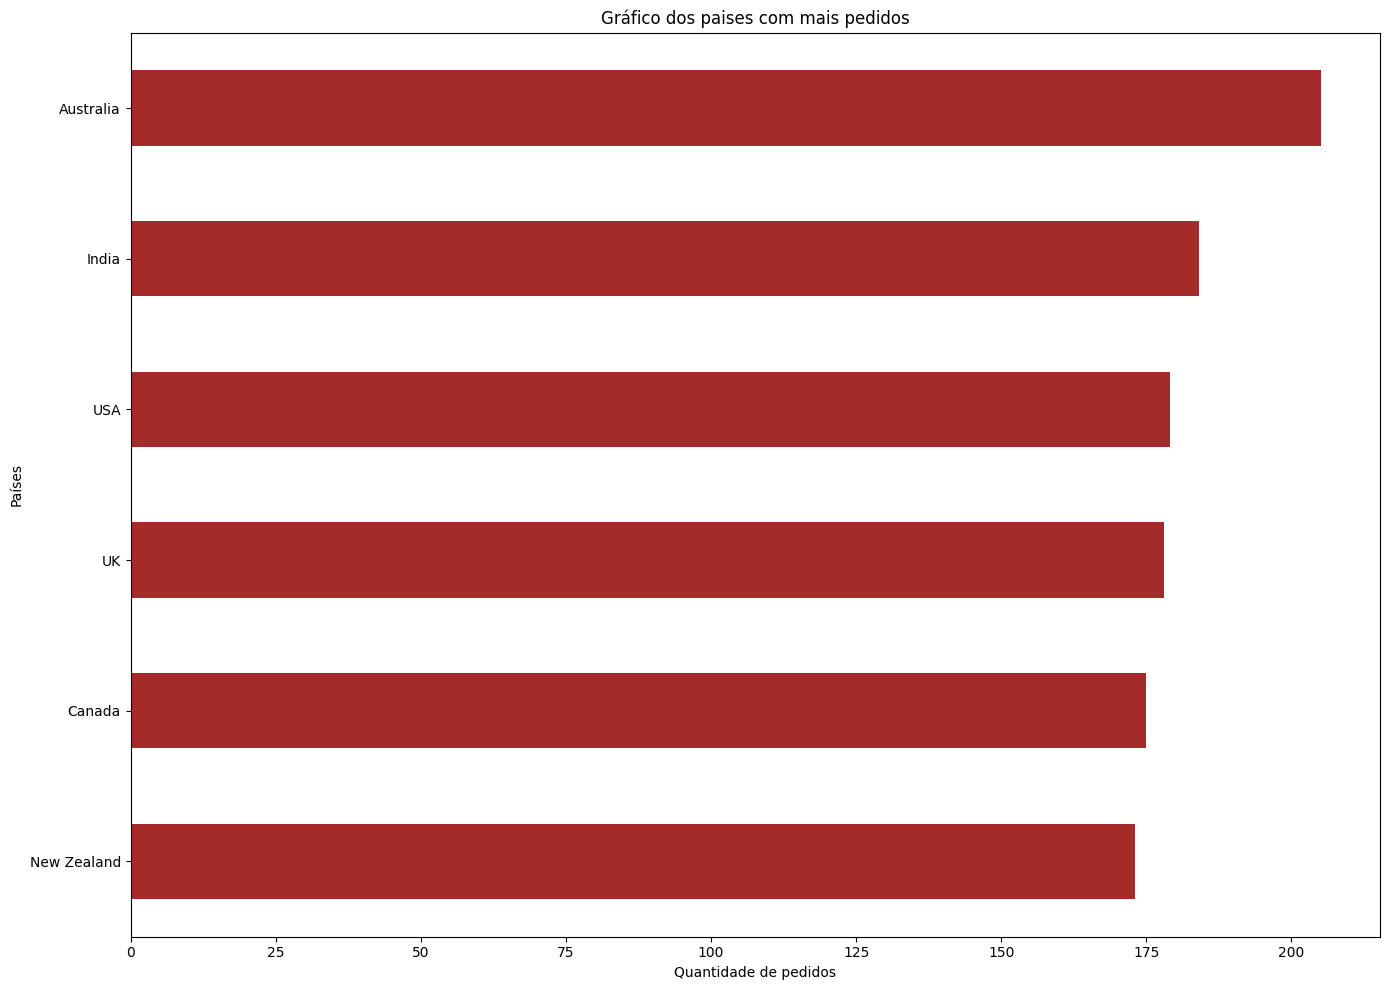

In [14]:
faturamento_pais_graf.plot(kind='barh', figsize=(14,10), color='brown')
plt.title('Gráfico dos paises com mais pedidos')
plt.xlabel('Quantidade de pedidos')
plt.ylabel('Países')
plt.tight_layout()
plt.show()

#A empresa quer enteder qual mês eles devem aumentar a produção de chocolates
Objetivo: Identificar em qual mês a empresa vende mais.

![Mais vendas](https://abisa.com.br/site/wp-content/uploads/Grafico-de-colunas-aumento-vendas.jpg)

Convertendo Date para datetime

In [15]:
dados_chocolate['Date'] = pd.to_datetime(dados_chocolate['Date'], format='%d-%b-%y')

Extraindo MÊS

In [16]:
dados_chocolate['Mes'] = dados_chocolate['Date'].dt.month

Calculando dados

In [17]:
vendas_por_mes = dados_chocolate.groupby('Mes')['Amount'].sum()

In [18]:
vendas_por_mes

,Amount
Mes,
1,896105.0
2,699377.0
3,749483.0
4,674051.0
5,752892.0
6,865144.0
7,803425.0
8,743148.0


#Gráfico das vendas em cada mês

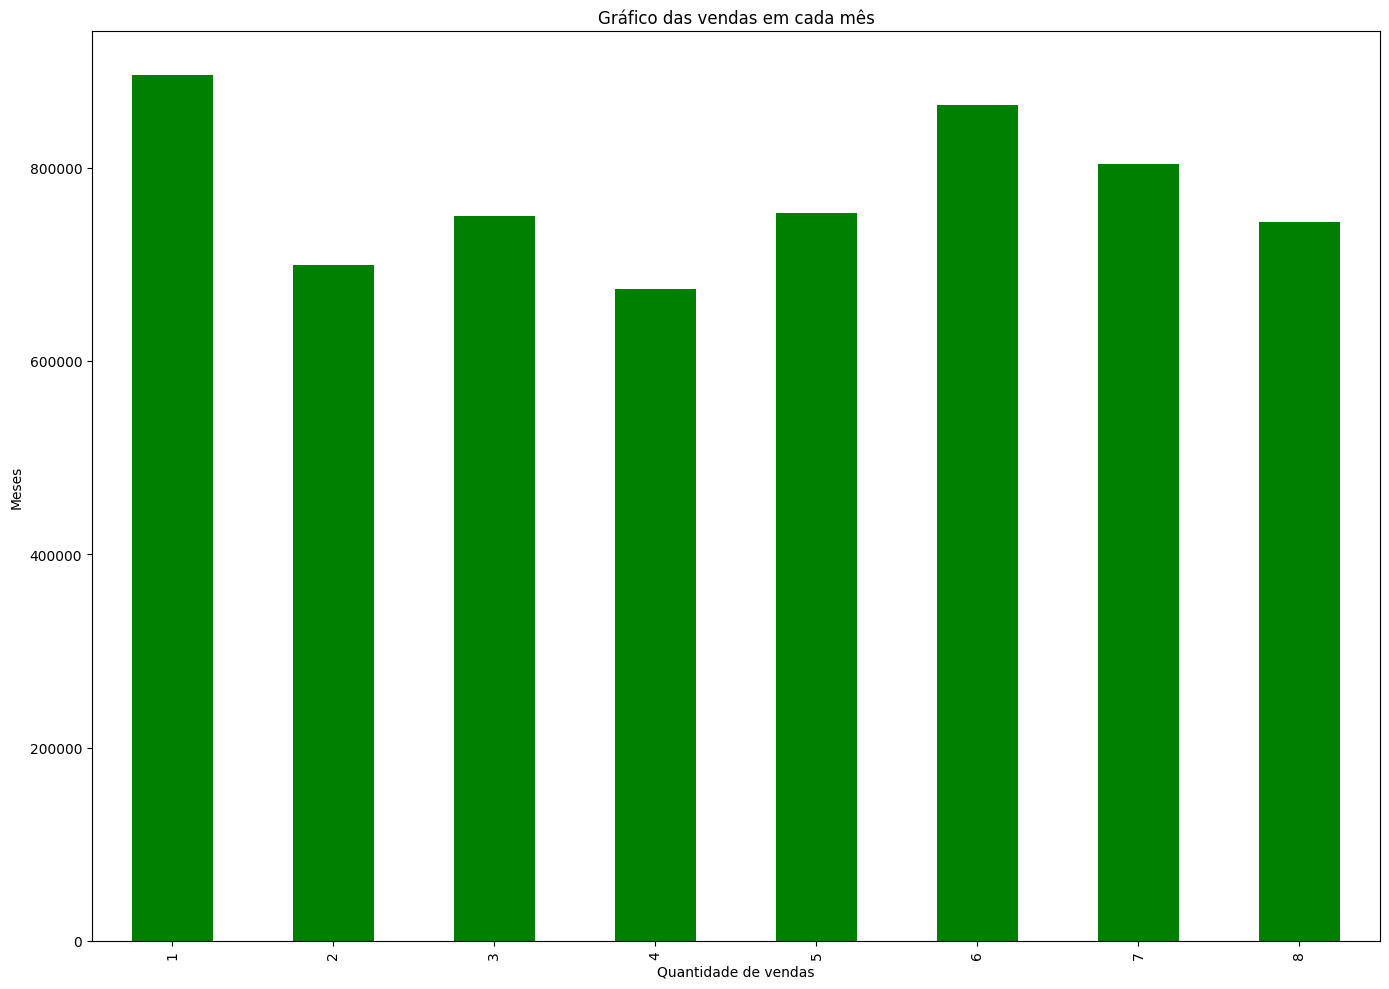

In [19]:
vendas_por_mes.plot(kind='bar', figsize=(14,10), color='green')
plt.title('Gráfico das vendas em cada mês')
plt.xlabel('Quantidade de vendas')
plt.ylabel('Meses')
plt.tight_layout()
plt.show()